In [18]:
# 학습된 모델 대신 직접 생성한 embedding을 사용(toy-embedding)
import math
import re
import pandas as pd
import torch
import torch.nn.functional as F

In [19]:
sentences = [
    '이 영화 정말 좋다',
    '이 영화 너무 지루하다',
    '배우 연기가 감동적이다',
    '전개는 보통이지만 마지막이 재미있다'
]

In [20]:
# toy-embedding : 2차원 벡터를 임의로 생성
# positive단어는 오른쪽 위 쪽에 배치
# negative 단어는 왼쪽 아래쪽에 배치
# neutal 단어는 원점 근처에 배치

# query와 비슷한 방향의 단어가 더 큰 score를 받음
toy_vocab = {
    '이': torch.tensor([0.0, 0.0]),
    '영화': torch.tensor([0.1, 0.0]),
    '정말': torch.tensor([0.0, 0.2]),
    '좋다': torch.tensor([1.2, 1.0]),
    '너무': torch.tensor([0.0, 0.1]),
    '지루하다': torch.tensor([-1.2, -1.0]),
    '배우': torch.tensor([0.2, 0.1]),
    '연기가': torch.tensor([0.3, 0.1]),
    '감동적이다': torch.tensor([1.0, 1.2]),
    '전개는': torch.tensor([0.0, 0.0]),
    '보통이지만': torch.tensor([0.0, 0.0]),
    '마지막이': torch.tensor([0.0, 0.1]),
    '재미있다': torch.tensor([1.1, 1.1]),
    '별로다': torch.tensor([-1.0, -1.1]),
    '최악이다': torch.tensor([-1.3, -1.2]),
}

positive_query = torch.tensor([1.0,1.0])
negative_query = torch.tensor([-1.0,-1.0])
toy_vocab['좋다'], positive_query, negative_query

(tensor([1.2000, 1.0000]), tensor([1., 1.]), tensor([-1., -1.]))

## 전처리 함수 만들기
- 문장을 토큰으로나눈뒤, 각 토큰을 toy embedding 벡터로 바꾼다
- 여기서 key value는 같은 벡터를 사용, query는 지금 찾고싶은 의미

In [21]:
def simple_tokenize(text: str):
    text = re.sub(r'[^가-힣\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    if not text:
        return []
    return text.split()

def get_token_vectors(tokens, vocab):
    vectors = []
    for token in tokens:
        vectors.append(vocab.get(token, torch.tensor([0.0, 0.0])))
    return torch.stack(vectors) if vectors else torch.empty(0, 2)

def attention_with_query(tokens, query, vocab):
    key = get_token_vectors(tokens, vocab)
    value = key

    if key.numel() == 0:
        return pd.DataFrame(), torch.tensor([])

    d_k = key.size(-1)
    scores = torch.matmul(key, query) / math.sqrt(d_k)
    weights = F.softmax(scores, dim=0)
    context = torch.sum(weights.unsqueeze(-1) * value, dim=0)

    frame = pd.DataFrame({
        'token': tokens,
        'key_x': key[:, 0].tolist(),
        'key_y': key[:, 1].tolist(),
        'score': scores.tolist(),
        'weight': weights.tolist(),
    })
    frame['value_x'] = frame['key_x']
    frame['value_y'] = frame['key_y']
    return frame, context

## 한문장에 query/ key /value 
- 첫번째 문장에 positive query를 넣어서 어떤 토큰이 더 중요한지 확인

In [22]:
toy_vocab

{'이': tensor([0., 0.]),
 '영화': tensor([0.1000, 0.0000]),
 '정말': tensor([0.0000, 0.2000]),
 '좋다': tensor([1.2000, 1.0000]),
 '너무': tensor([0.0000, 0.1000]),
 '지루하다': tensor([-1.2000, -1.0000]),
 '배우': tensor([0.2000, 0.1000]),
 '연기가': tensor([0.3000, 0.1000]),
 '감동적이다': tensor([1.0000, 1.2000]),
 '전개는': tensor([0., 0.]),
 '보통이지만': tensor([0., 0.]),
 '마지막이': tensor([0.0000, 0.1000]),
 '재미있다': tensor([1.1000, 1.1000]),
 '별로다': tensor([-1.0000, -1.1000]),
 '최악이다': tensor([-1.3000, -1.2000])}

In [23]:
sentence = sentences[0]
tokens = simple_tokenize(sentence)
frame,context = attention_with_query(tokens,positive_query,toy_vocab)
print('sentence:', sentence)
print('tokens:', tokens)
print('query:',positive_query.tolist())
print('context:',context.tolist())
display(frame.sort_values('weight', ascending=False).reset_index(drop=True))

sentence: 이 영화 정말 좋다
tokens: ['이', '영화', '정말', '좋다']
query: [1.0, 1.0]
context: [0.7274695634841919, 0.6239237189292908]


,token,key_x,key_y,score,weight,value_x,value_y
0,좋다,1.2,1.0,1.555635,0.594993,1.2,1.0
1,정말,0.0,0.2,0.141421,0.144653,0.0,0.2
2,영화,0.1,0.0,0.070711,0.134778,0.1,0.0
3,이,0.0,0.0,0.000000,0.125576,0.0,0.0


- 의미해석 : 각 토큰을 toy-vector로 바뀐뒤 query와 의 유사도를 계산
- weight 는 score에 softmax를 적용한 확률기반의 점수
- 모델은 이문장에서 좋다 라는 단어를 중요하게 본다
- context: [0.7274695634841919, 0.6239237189292908]는 이 가중치를 반영해 만든 문장요약 벡터
- 결국 attention은 문장 전테를 다 똑같이 보지 않고 지금 query와 가장 관련있는 단어에 집중한다 

```
query = 지금 찾고 싶은 감정 방향
key = 각 단어가 가진 특징
score = query와 key가 얼마나 비슷한가
weight = score를 확률처럼 바꾼 값
context = weight로 단어들을 섞어 만든 최종 요약
```

## 같은 문장을 positive query와 negative query로 비교

query가 바뀌면 attention weight도 바뀐다.

- positive query: 좋은 단어 쪽을 더 본다.
- negative query: 나쁜 단어 쪽을 더 본다.

In [24]:
compare_sentence = '이 영화 정말 좋다 하지만 마지막이 별로다'
tokens = simple_tokenize(compare_sentence)
pos_trame, pos_context = attention_with_query(tokens,positive_query,toy_vocab)
neg_trame, neg_context = attention_with_query(tokens,negative_query,toy_vocab)

print('sentence:', sentence)
print('tokens:', tokens)
print('query:',positive_query.tolist())
print('context:',pos_context.tolist())
display(pos_trame.sort_values('weight', ascending=False).reset_index(drop=True))

print('sentence:', sentence)
print('tokens:', tokens)
print('query:',negative_query.tolist())
print('context:',neg_context.tolist())
display(neg_trame.sort_values('weight', ascending=False).reset_index(drop=True))

sentence: 이 영화 정말 좋다
tokens: ['이', '영화', '정말', '좋다', '하지만', '마지막이', '별로다']
query: [1.0, 1.0]
context: [0.5423838496208191, 0.47029146552085876]


,token,key_x,key_y,score,weight,value_x,value_y
0,좋다,1.2,1.0,1.555635,0.461665,1.2,1.0
1,정말,0.0,0.2,0.141421,0.112238,0.0,0.2
2,영화,0.1,0.0,0.070711,0.104576,0.1,0.0
3,마지막이,0.0,0.1,0.070711,0.104576,0.0,0.1
4,이,0.0,0.0,0.000000,0.097437,0.0,0.0
5,하지만,0.0,0.0,0.000000,0.097437,0.0,0.0
6,별로다,-1.0,-1.1,-1.484924,0.022071,-1.0,-1.1


sentence: 이 영화 정말 좋다
tokens: ['이', '영화', '정말', '좋다', '하지만', '마지막이', '별로다']
query: [-1.0, -1.0]
context: [-0.43476250767707825, -0.46789708733558655]


,token,key_x,key_y,score,weight,value_x,value_y
0,별로다,-1.0,-1.1,1.484924,0.471786,-1.0,-1.1
1,이,0.0,0.0,0.000000,0.106869,0.0,0.0
2,하지만,0.0,0.0,0.000000,0.106869,0.0,0.0
3,영화,0.1,0.0,-0.070711,0.099573,0.1,0.0
4,마지막이,0.0,0.1,-0.070711,0.099573,0.0,0.1
5,정말,0.0,0.2,-0.141421,0.092775,0.0,0.2
6,좋다,1.2,1.0,-1.555635,0.022555,1.2,1.0


## 여러 문장 한 번에 비교

문장마다 어떤 단어에 attention이 많이 가는지 표로 비교한다.

In [25]:
rows = []
for sentence in sentences:
    tokens = simple_tokenize(sentence)
    frame, context = attention_with_query(tokens, positive_query, toy_vocab)
    if len(frame) == 0:
        rows.append({
            'sentence': sentence,
            'top_token': None,
            'top_weight': None,
            'context_x': None,
            'context_y': None,
        })
        continue

    top_row = frame.sort_values('weight', ascending=False).iloc[0]
    rows.append({
        'sentence': sentence,
        'top_token': top_row['token'],
        'top_weight': round(float(top_row['weight']), 4),
        'context_x': round(float(context[0]), 4),
        'context_y': round(float(context[1]), 4),
    })

summary = pd.DataFrame(rows)
summary

,sentence,top_token,top_weight,context_x,context_y
0,이 영화 정말 좋다,좋다,0.5950,0.7275,0.6239
1,이 영화 너무 지루하다,영화,0.3197,-0.0435,-0.0309
2,배우 연기가 감동적이다,감동적이다,0.6489,0.7373,0.8138
3,전개는 보통이지만 마지막이 재미있다,재미있다,0.6066,0.6672,0.6810


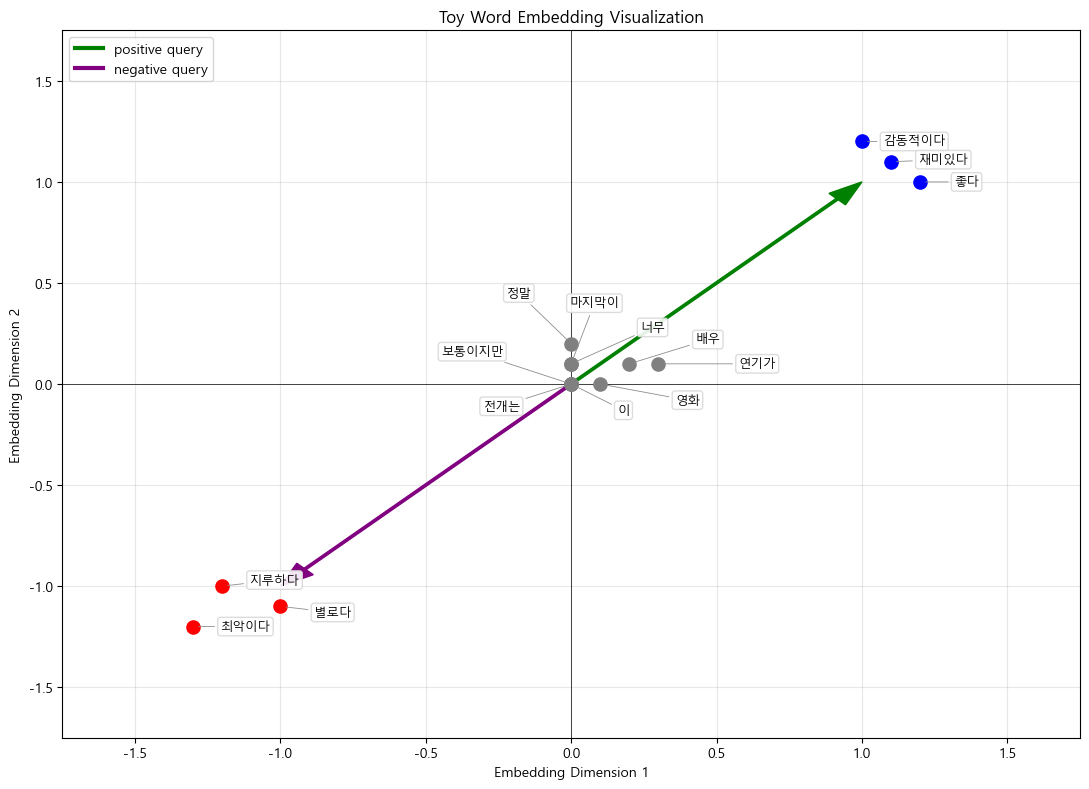

In [26]:
# 내가 추가(지피티)
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------------
# 한글 폰트 설정
# -------------------------
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# -------------------------
# 시각화
# -------------------------
fig, ax = plt.subplots(figsize=(11, 8))

# 가까운 좌표에 몰린 단어들이 겹치지 않도록 라벨 위치를 직접 벌린다.
label_offsets = {
    '이': (0.18, -0.13),
    '영화': (0.30, -0.08),
    '정말': (-0.18, 0.25),
    '너무': (0.28, 0.18),
    '배우': (0.27, 0.12),
    '연기가': (0.34, 0.00),
    '전개는': (-0.24, -0.11),
    '보통이지만': (-0.34, 0.16),
    '마지막이': (0.08, 0.30),
    '좋다': (0.16, 0.00),
    '감동적이다': (0.18, 0.00),
    '재미있다': (0.18, 0.01),
    '지루하다': (0.18, 0.03),
    '별로다': (0.18, -0.03),
    '최악이다': (0.18, 0.00),
}

for word, vec in toy_vocab.items():
    x, y = vec.tolist()

    # 색상 규칙
    if x > 0.5 and y > 0.5:
        color = 'blue'       # positive
    elif x < -0.5 and y < -0.5:
        color = 'red'        # negative
    else:
        color = 'gray'       # neutral

    ax.scatter(x, y, color=color, s=90, zorder=3)

    dx, dy = label_offsets.get(word, (0.12, 0.08))
    ax.annotate(
        word,
        xy=(x, y),
        xytext=(x + dx, y + dy),
        fontsize=9,
        ha='center',
        va='center',
        bbox=dict(boxstyle='round,pad=0.22', fc='white', ec='0.85', alpha=0.9),
        arrowprops=dict(arrowstyle='-', color='0.55', lw=0.6, shrinkA=2, shrinkB=4),
        zorder=4,
    )

# query 벡터 표시
ax.arrow(
    0, 0,
    positive_query[0], positive_query[1],
    color='green',
    width=0.01,
    head_width=0.08,
    length_includes_head=True,
    zorder=2,
)

ax.arrow(
    0, 0,
    negative_query[0], negative_query[1],
    color='purple',
    width=0.01,
    head_width=0.08,
    length_includes_head=True,
    zorder=2,
)

# 축
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)

ax.set_xlim(-1.75, 1.75)
ax.set_ylim(-1.75, 1.75)

ax.set_title('Toy Word Embedding Visualization')
ax.set_xlabel('Embedding Dimension 1')
ax.set_ylabel('Embedding Dimension 2')
ax.grid(True, alpha=0.3)

legend_handles = [
    Line2D([0], [0], color='green', lw=3, label='positive query'),
    Line2D([0], [0], color='purple', lw=3, label='negative query'),
]
ax.legend(handles=legend_handles, loc='upper left')

plt.tight_layout()
plt.show()
